#**Task 1 — Data Loading & Exploration**

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('Housing.csv')

In [4]:
print("First 10 rows of the dataset:")
display(df.head(10))

First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Check how many rows and columns are there

In [5]:
print("\nTotal Rows and Columns:", df.shape)


Total Rows and Columns: (545, 13)


Check for missing values in each column

In [6]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Identify target and features

In [7]:
print("\nTarget Column: 'price'")
print("Feature Columns:", [col for col in df.columns if col != 'price'])


Target Column: 'price'
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


# **Task 2 — Data Cleaning**

In [8]:
df = df.dropna()

In [9]:
df = df.drop_duplicates()

Convert categorical columns (e.g., yes/no fields) into numeric using one-hot encoding

drop_first=True helps avoid the dummy variable trap

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
print("Cleaned data shape after encoding:", df.shape)
display(df.head())

Cleaned data shape after encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


# **Task 3 — Model Building**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Split the data into features (X) and target (y)

In [13]:
X = df.drop('price', axis=1) # Assuming target column is 'price'
y = df['price']

Split into training and test sets (80/20)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### --- Linear Regression Model ---

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [16]:
print("--- Linear Regression Performance ---")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R² Score:", r2_score(y_test, lr_preds))

--- Linear Regression Performance ---
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


### --- Random Forest Regressor Model ---

In [17]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [18]:
print("\n--- Random Forest Regressor Performance ---")
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R² Score:", r2_score(y_test, rf_preds))


--- Random Forest Regressor Performance ---
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


# **Task 4 — Visualization**

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

Create the charts directory

In [20]:
os.makedirs('charts', exist_ok=True)


Chart 1: Histogram showing the distribution of house prices

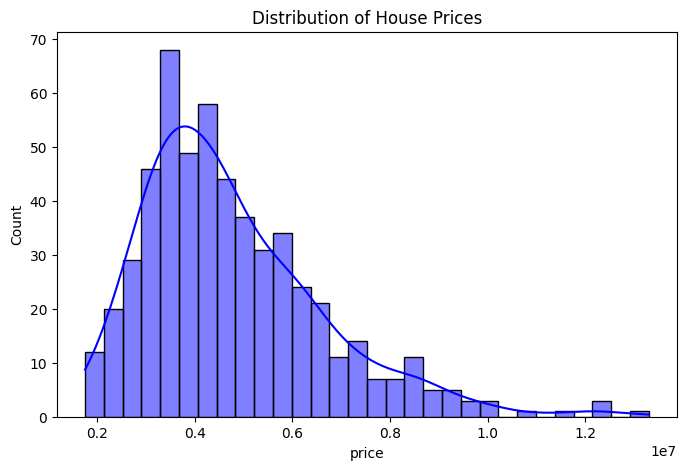

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='blue', bins=30)
plt.title('Distribution of House Prices')
plt.savefig('charts/histogram.png')
plt.show()

 Chart 2: Correlation heatmap showing which features relate most strongly to price


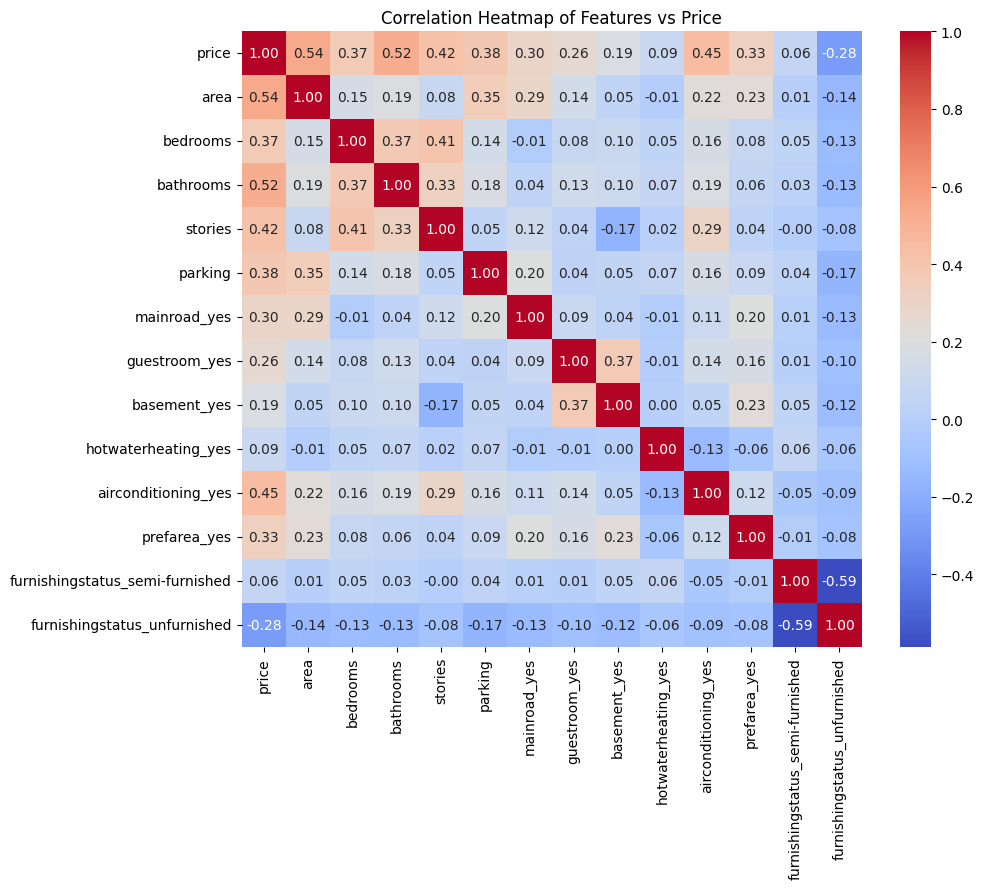

In [23]:
plt.figure(figsize=(10, 8))
# Calculate correlation matrix
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features vs Price')
plt.savefig('charts/heatmap.png')
plt.show()



Chart 3: Custom Chart (Price vs Area scatter plot)

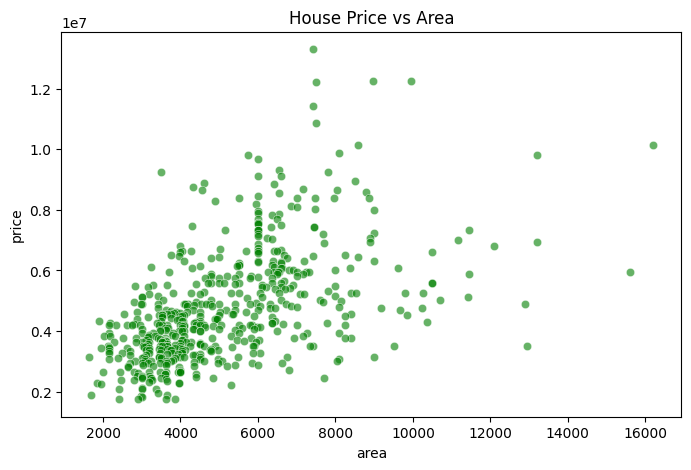

In [24]:
plt.figure(figsize=(8, 5))
# Assuming the area column is named 'area'
sns.scatterplot(x='area', y='price', data=df, color='green', alpha=0.6)
plt.title('House Price vs Area')
plt.savefig('charts/scatter_plot.png')
plt.show()

Chart 4: Actual vs. Predicted Prices (Linear Regression)

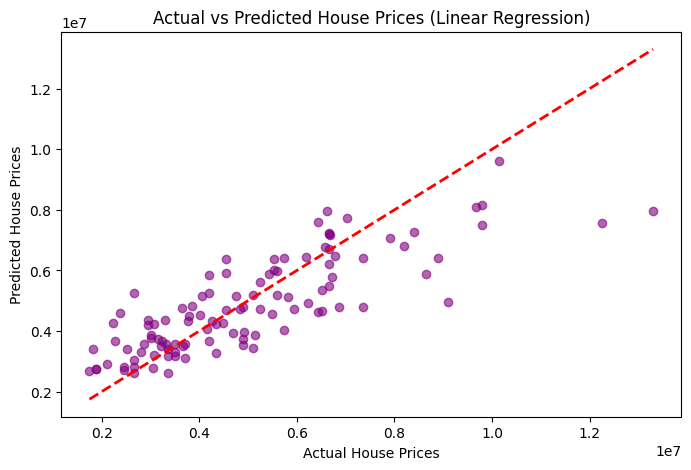

In [25]:
# This chart checks how close your model's predictions are to the real prices.
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_preds, alpha=0.6, color='purple')
# Adding a red dashed line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices (Linear Regression)')
plt.savefig('charts/actual_vs_predicted.png')
plt.show()

Chart 5: Boxplot of Price based on Air Conditioning

/tmp/ipykernel_1220/2908763155.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airconditioning_yes', y='price', data=df, palette='Set2')


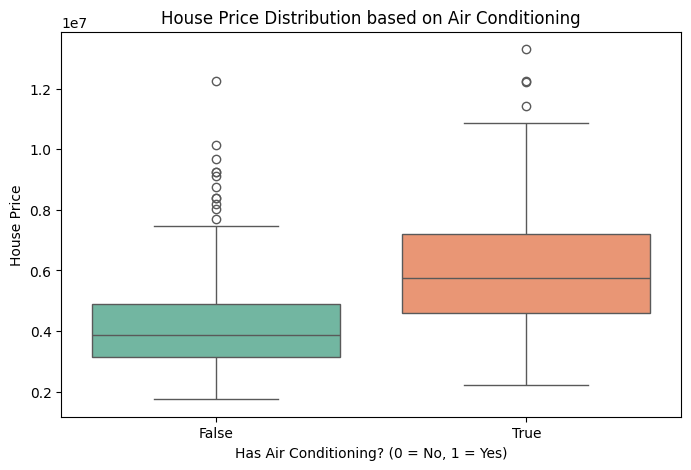

In [26]:
# Since our heatmap showed air conditioning has a strong correlation (0.45) with price,
# a boxplot will visualize the exact price difference between houses with and without it.
plt.figure(figsize=(8, 5))
# Note: after get_dummies, 'airconditioning' becomes 'airconditioning_yes'
sns.boxplot(x='airconditioning_yes', y='price', data=df, palette='Set2')
plt.title('House Price Distribution based on Air Conditioning')
plt.xlabel('Has Air Conditioning? (0 = No, 1 = Yes)')
plt.ylabel('House Price')
plt.savefig('charts/boxplot_aircond.png')
plt.show()

Chart 6: Average House Price by Number of Bathrooms

/tmp/ipykernel_1220/1440908547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bathrooms', y='price', data=df, palette='muted', errorbar=None)


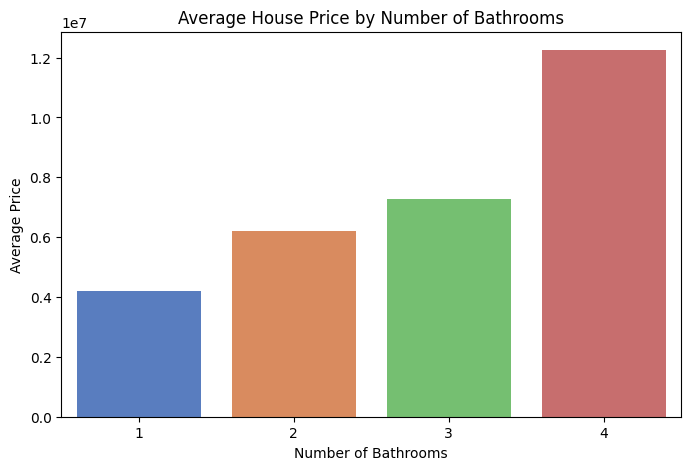

In [27]:
# Bathrooms had a very high correlation (0.52) with price.
# A bar plot easily shows how the average price scales with the number of bathrooms.
plt.figure(figsize=(8, 5))
# Using ci=None to remove the error bars for a cleaner look
sns.barplot(x='bathrooms', y='price', data=df, palette='muted', errorbar=None)
plt.title('Average House Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Average Price')
plt.savefig('charts/barplot_bathrooms.png')
plt.show()

# **Task 5 — Insights & Summary**

**1. Most influential features:** Based on the correlation heatmap, the features that most strongly influence the house price are the **area** (0.54) and the number of **bathrooms** (0.52) followed by AC(0.45) and Stories(0.42). The new boxplot also visually highlights that having **air conditioning** drastically shifts the median house price upward.

**2. Model accuracy:** In plain terms, the **Linear Regression** model performed best, successfully explaining about **65.3%** of the variance in house prices. However, as shown in the "Actual vs. Predicted" chart, while the model is quite accurate for standard homes, it tends to underpredict the prices of luxury/high-end homes.


**3. Surprises in the data:** I was surprised to find that the Random Forest model underperformed the simpler Linear Regression model. Additionally, features like having hot water heating (0.09) or being semi-furnished (0.06) have surprisingly little to no impact on the final house price.


**4. Business Recommendation:** Based on these findings, a real estate business should focus primarily on marketing homes with larger square footage, more bathrooms, and air conditioning, as these yield the highest return on property value. Furthermore, the business should not rely solely on this regression model to appraise ultra-luxury homes, as it tends to undervalue them.